# sRCS Personality Table Demonstration

**09/05/2024 work in progress**

Prepared by Lane Meier - lane.a.meier@nasa.gov

For convenience the Wide Field Instrument's Simplified Relative Calibration System performance parameters have been gathered into a single easily readable file.

This is an Excel file with sheets for Photodiode performance, LED performance, LED to FPA flux mapping used in TVAC1 & TVAC2, measured LED spectrum

## Reading the File

The easiest way to read the file is with the `pandas.read_excel` function. Sheetname must be specified since the file has multiple sheets.

Furthermore, there are two ways to read the file. Using _verbose_ column names or _short hand_

### Verbose column names

Verbose column names are generally longer and more descriptibe. Ex: 'Noise without integrator [uV rms]'. The units are always found within brackets `[]` and can be pulled out via parallel dictionary
Ex:

In [1]:
import pandas as pd

# skip rows 0 & 2 for verbose column names
pd_data_verbose = pd.read_excel("sRCS_PersonalityTable.xlsx", skiprows=[0,2], sheet_name="Photodiodes")
pd_data_verbose

,Per Photodiode Performance Markers,side,number,material,Noise without integrator [uV rms],Noise with integrator [uV rms],Which LED band PD is usable with,"Rizzo: Linearity [%/4.5 decades] (side-B TVAC2, TVAC1 with caveat) wl dependent?",B1 FPA [e-/pix/s per V],B2 FPA [e-/pix/s per V],...,B4 FPA [e-/pix/s per V],B5 FPA [e-/pix/s per V],B6 FPA [e-/pix/s per V],B1 high gain max flux [e-/pix/s],B2 high gain max flux [e-/pix/s],B3 high gain max flux [e-/pix/s],B4 high gain max flux [e-/pix/s],B5 high gain max flux [e-/pix/s],B6 high gain max flux [e-/pix/s],Low to High Gain [Vhigh/Vlow]
0,NaN,A,1,InGaAs [Indium Gallium Arsenide],0.50,*0.27,"1,2,3,4,5",Poor,5508,4519,...,4817,5167,27476,13770,11298,11515,12041,12918,68689,11.05
1,NaN,A,2,MCT [Mercury Cadmium Telurride],32.00,*10,"1,2,3,4,5,6",Excellent,6279,4764,...,5737,6024,6191,15698,11910,13306,14342,15060,15477,11.02
2,NaN,B,1,InGaAs [Indium Gallium Arsenide],0.68,0.27,"1,2,3,4,5",Poor,5447,4393,...,4673,5015,28994,13618,10984,11075,11682,12537,72484,11.09
3,NaN,B,2,MCT [Mercury Cadmium Telurride],0.80,0.48,"1,2,3,4,5,6",Excellent,5849,4565,...,5509,5787,5967,11413,11413,12852,13773,14467,14919,11.05


### Shorthand Column Names

In [2]:
# skip rows 0 & 1 for shorthand column names
pd_data_short_hand = pd.read_excel("sRCS_PersonalityTable.xlsx", skiprows=[0,1], sheet_name="Photodiodes")
pd_data_short_hand

,shorthand,side,number,material,noise_uV,noise_int_uV,valid_band,linearity,b1_epsperV,b2_epsperV,...,b4_epsperV,b5_epsperV,b6_epsperV,b1_max_eps,b2_max_eps,b3_max_eps,b4_max_eps,b5_max_eps,b6_max_eps,low_to_high_gain
0,NaN,A,1,InGaAs [Indium Gallium Arsenide],0.50,*0.27,"1,2,3,4,5",Poor,5508,4519,...,4817,5167,27476,13770,11298,11515,12041,12918,68689,11.05
1,NaN,A,2,MCT [Mercury Cadmium Telurride],32.00,*10,"1,2,3,4,5,6",Excellent,6279,4764,...,5737,6024,6191,15698,11910,13306,14342,15060,15477,11.02
2,NaN,B,1,InGaAs [Indium Gallium Arsenide],0.68,0.27,"1,2,3,4,5",Poor,5447,4393,...,4673,5015,28994,13618,10984,11075,11682,12537,72484,11.09
3,NaN,B,2,MCT [Mercury Cadmium Telurride],0.80,0.48,"1,2,3,4,5,6",Excellent,5849,4565,...,5509,5787,5967,11413,11413,12852,13773,14467,14919,11.05


#### Getting Units

Examples below show a way to correspond units to columns depending on the verbosity of the column

These simply use `[unit]` to find units in verbose mode or the last `_unit` in shorthand and put it in a dictionary for reference. This convention is used throughout the files

In [3]:
import re
import astropy.units as u

# grab verbose version units
def get_verb_units(df):
    units = dict()
    for k in df.columns:
        match = re.search(r'\[.*\]', k)
        if match:
            units[k] = match[0]
        else:
            units[k] = 'UNKNOWN'

    return units


get_verb_units(pd_data_verbose)

{'Per Photodiode Performance Markers': 'UNKNOWN',
 'side': 'UNKNOWN',
 'number': 'UNKNOWN',
 'material': 'UNKNOWN',
 'Noise without integrator [uV rms]': '[uV rms]',
 'Noise with integrator [uV rms]': '[uV rms]',
 'Which LED band PD is usable with': 'UNKNOWN',
 'Rizzo: Linearity [%/4.5 decades] (side-B TVAC2, TVAC1 with caveat) wl dependent?': '[%/4.5 decades]',
 'B1 FPA [e-/pix/s per V]': '[e-/pix/s per V]',
 'B2 FPA [e-/pix/s per V]': '[e-/pix/s per V]',
 'B3 FPA [e-/pix/s per V]': '[e-/pix/s per V]',
 'B4 FPA [e-/pix/s per V]': '[e-/pix/s per V]',
 'B5 FPA [e-/pix/s per V]': '[e-/pix/s per V]',
 'B6 FPA [e-/pix/s per V]': '[e-/pix/s per V]',
 'B1 high gain max flux [e-/pix/s]': '[e-/pix/s]',
 'B2 high gain max flux [e-/pix/s]': '[e-/pix/s]',
 'B3 high gain max flux [e-/pix/s]': '[e-/pix/s]',
 'B4 high gain max flux [e-/pix/s]': '[e-/pix/s]',
 'B5 high gain max flux [e-/pix/s]': '[e-/pix/s]',
 'B6 high gain max flux [e-/pix/s]': '[e-/pix/s]',
 'Low to High Gain [Vhigh/Vlow]': '[Vhigh

In [4]:
def get_short_units(df):
    units = dict()
    for k in df.columns:
        if '_' in k:
            units[k] = k.split('_')[-1]
        else:
            units[k] = 'UNK'
    return units

get_short_units(pd_data_short_hand)

{'shorthand': 'UNK',
 'side': 'UNK',
 'number': 'UNK',
 'material': 'UNK',
 'noise_uV': 'uV',
 'noise_int_uV': 'uV',
 'valid_band': 'band',
 'linearity': 'UNK',
 'b1_epsperV': 'epsperV',
 'b2_epsperV': 'epsperV',
 'b3_epsperV': 'epsperV',
 'b4_epsperV': 'epsperV',
 'b5_epsperV': 'epsperV',
 'b6_epsperV': 'epsperV',
 'b1_max_eps': 'eps',
 'b2_max_eps': 'eps',
 'b3_max_eps': 'eps',
 'b4_max_eps': 'eps',
 'b5_max_eps': 'eps',
 'b6_max_eps': 'eps',
 'low_to_high_gain': 'gain'}

#### Astropy Units

Generally Astropy units are not supported for e- which is used in many of the sRCS personality tables. This can be worked around by with `parse_strict='silent'`. However, many of the benefits of using astropy units are lost due to this.



In [5]:
import astropy.units as u

eps = u.Unit('e-/pix/s', parse_strict='silent')

eps

UnrecognizedUnit(e-/pix/s)

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib widget
plt.rcParams['font.family'] = 'Times New Roman'

# skip rows 0 & 2 for verbose column names
led = pd.read_excel("sRCS_PersonalityTable.xlsx", skiprows=[0,2], sheet_name="LEDs")
list(led.columns)

['Side',
 'Band',
 'Bank',
 'LED#',
 'LEDPSN',
 'LED Shorthand [SideBandBank]',
 'Center wavelength [nm]',
 'Wavelength FWHM [nm]',
 'Wavelength vs temperature [nm/K]',
 'Minimum flux measured [e-/pix/s]',
 'Maximum flux projected [e-/pix/s]',
 'Percent of max flux requirement [%]',
 'Repeatability over 2 Hours no fV correct [%]',
 'Repeatability over 2 Hours with fV correct [%]',
 'Settling over 300 seconds at 60 e-/pix/s no precharge [%]',
 'Settling over 300 seconds at 60 e-/pix/s with precharge [%]',
 'Thermal Drift at High Current [%]',
 'Flux Gap [bool]',
 'Max of Low Current Range [e-/pix/s]',
 'Minimum of High Current Range [e-/pix/s]',
 'gap amount [e-/pix/s]',
 'Recommended precharge required [mAprecharge*seconds/mAfinal]',
 'Precharge Min [e-/pix/s]',
 'Precharge Max [e-/pix/s]',
 'LED hysteresis [does using LED at high current change future results]',
 'Dark Element Peak to Valley [%]',
 'LOLO Peak to Valley [%]',
 'LOLO Pixels Passing 25% Uniformity',
 'Quantify the noise 

## Examples with LED Performance Data

Below is an example plotting min / max ranges per LED

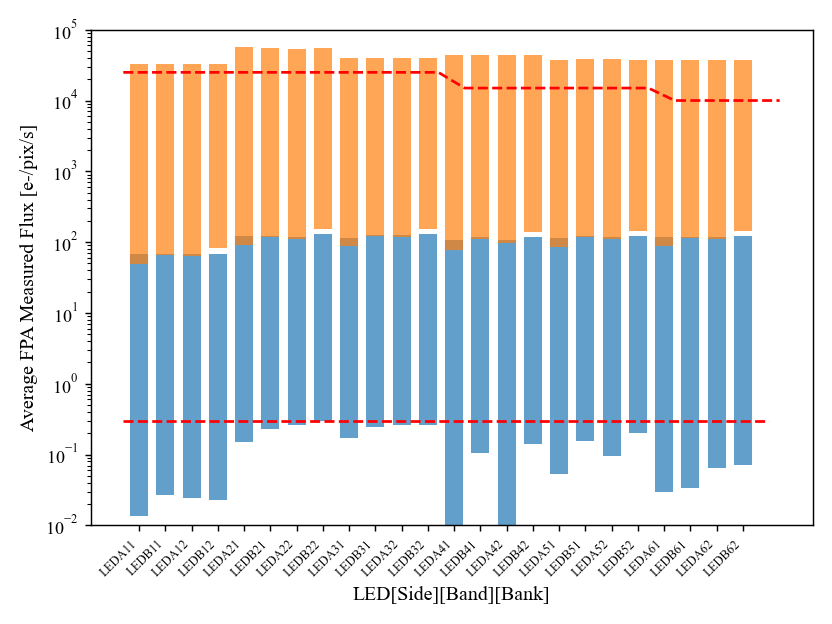

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib widget
plt.rcParams['font.family'] = 'Times New Roman'

# skip rows 0 & 2 for verbose column names
led = pd.read_excel("sRCS_PersonalityTable.xlsx", skiprows=[0,2], sheet_name="LEDs")

# Showing keys used for min / max of high and low range
minlr_key = 'Minimum flux measured [e-/pix/s]'
maxlr_key = 'Max of Low Current Range [e-/pix/s]'
minhr_key = 'Minimum of High Current Range [e-/pix/s]'
maxhr_key = 'Maximum flux projected [e-/pix/s]'

# Sorting LEDs to desired order.. Bank then Side then Band
led = led.sort_values(by=['Band', 'Bank', 'Side'])
fig = plt.figure(dpi=130)

# iterate through the list of LEDs
for i in range(0, len(led)):
    r = led.iloc[i]
    minlr = r[minlr_key]
    maxlr = r[maxlr_key]
    minhr = r[minhr_key]
    maxhr = r[maxhr_key]
    
    # plot the bar for low range
    plt.plot([i, i], [minlr, maxlr], alpha=0.7, linestyle='-', linewidth=10, color='C0', solid_capstyle='butt')
    
    # plot the bar for high range
    plt.plot([i, i], [minhr, maxhr], alpha=0.7, linestyle='-', linewidth=10, color='C1', solid_capstyle='butt')

# perform plot formatting / Labeling
plt.yscale('log')
plt.gca().set_xticks(range(0, len(led)))
plt.gca().set_xticklabels(led["LED Shorthand [SideBandBank]"].values, fontsize=7, rotation=45, ha='right')
plt.ylim([1e-2, 1e5])
plt.ylabel('Average FPA Measured Flux [e-/pix/s]', fontsize=11)
plt.xlabel('LED[Side][Band][Bank]', fontsize=11)
# plt.title('RCS flux range', fontsize=11)
plt.plot([-.6, len(led)], [.3, .3], 'r--')
plt.plot(np.arange(-.6, 24.6), 13*[25000] + 8*[15000] + 5*[10000], 'r--')
fig.set_tight_layout(True)
fig.savefig('RCS_flux_range.png')


In [8]:
12*[25000] + 8*[15000] + 4*[10000]

[25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 25000,
 15000,
 15000,
 15000,
 15000,
 15000,
 15000,
 15000,
 15000,
 10000,
 10000,
 10000,
 10000]

## Examples with Spectrum Data

Text(0.5, 0, 'Wavelength [nm]')

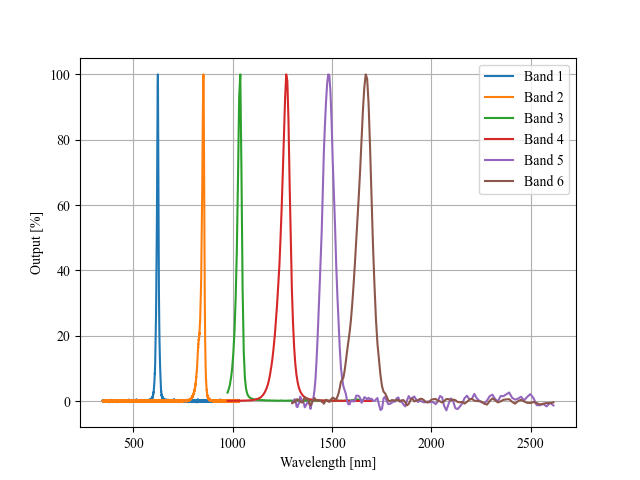

In [9]:
spectrum = pd.read_excel("sRCS_PersonalityTable.xlsx", skiprows=[0,2], sheet_name="LED Spectrum")
plt.figure()
for band in range(1, 7):
    spectrum.plot(x=f'B{band} wavelength [nm]', y=f'B{band} output [%]', ax=plt.gca(), label=f'Band {band}')
plt.grid(True)
plt.ylabel('Output [%]')
plt.xlabel('Wavelength [nm]')

## Inferring Flux / Current / Code in WFI TVAC1 & WFI TVAC2

In [10]:
import numpy as np
from collections import namedtuple
# NOTE: ftoc is a DataFrame used in the subsequent functions - it reads the calibration table 
# from TVAC1 & TVAC2
ftoc = pd.read_excel("sRCS_PersonalityTable.xlsx", skiprows=[0,2], sheet_name="WFI TVAC1 and TVAC2 Flux Table")

def hex_to_current(side, bank, code) -> float:
    """The equivalent programmed register code [DN] for side, bank, and band in current.

    Args:
        side (char): sRCS side. side='A' or side='B'
        bank (int): the srcs bank being used Ex: bank=1, or bank=2
        code (int): The code being programmed into the current register. Ex: code=67888

    Returns:
        float: current in Amps [A]
    """
    box = dict()
    if np.isnan(code):
        return 0
    _cmd_curve = namedtuple('Curve',['m','b'])
    if side.upper() == 'A':
        # Curves for Flight 1 sRCSE at Cold (-31C avg)
        B1_high_curve = _cmd_curve(683507.4843, 65462.8064)
        B1_low_curve = _cmd_curve(273944015.3, -76.47924149)
        B1_ultralow_curve = _cmd_curve(253674929.9, 164.1452529)
        B2_high_curve = _cmd_curve(684726.3488, 65387.38867)
        B2_low_curve = _cmd_curve(274525613.8, -147.0222373)
        B2_ultralow_curve = _cmd_curve(247294249, 83.70018248)
    elif side.upper() == 'B':
        # Curves for Flight 2 sRCSE at Cold (-31C avg)
        B1_high_curve = _cmd_curve(685056.77, 65382.47331)
        B1_low_curve = _cmd_curve(274557986.4, -153.1971136)
        B1_ultralow_curve = _cmd_curve(243116093.8, 93.3474194)
        B2_high_curve = _cmd_curve(685523.0879, 65347.46843)
        B2_low_curve = _cmd_curve(274952369.8, -166.1840521)
        B2_low_curve = _cmd_curve(245341211.5, 32.21601601)
    code = int(code)
    if bank == 1:
        high_curve = B1_high_curve
        low_curve = B1_low_curve
        ultra_low_curve = B1_ultralow_curve
    elif bank == 2:
        high_curve = B2_high_curve
        low_curve = B2_low_curve
        ultra_low_curve = B2_low_curve
    current = 0
    if np.isnan(code):
        current = 0
    if code > 65536:    # Bit 16 (range high/low) is set
        current = (code - high_curve.b) / high_curve.m
    elif code <= 65535:
        current = (code - low_curve.b) / low_curve.m
    return round(current,10)


def hex_to_current_mA(side, bank, code) -> float:
    """The equivalent programmed register code [DN] for side, bank, and band in current mA.

    Args:
        side (char): sRCS side. side='A' or side='B'
        bank (int): the srcs bank being used Ex: bank=1, or bank=2
        code (int): The code being programmed into the current register. Ex: code=67888

    Returns:
        float: current in milli Amps [mA]
    """
    return hex_to_current(side, bank, code)*1e3


def hex_to_current_str(side, bank, code):
    """The equivalent programmed register code [DN] for side, bank, and band in current.
        This function returns a readable string and does appropriate truncatin of decimals.
    Args:
        side (char): sRCS side. side='A' or side='B'
        bank (int): the srcs bank being used Ex: bank=1, or bank=2
        code (int): The code being programmed into the current register. Ex: code=67888

    Returns:
        str: current as an easy to read string
    """
    c = hex_to_current(side, bank, code)
    if c < 1e-4:
        ret = f'{c*1e6:.0f}µA'
    elif c < 1e-1:
        ret = f'{c*1e3:.2f}mA'
    else:
        ret = f'{c:.2f}A'

    return ret


def current_to_hex(side, bank, current) -> int:
    """Find out the appropriate programmable code given side, bank, current

    Args:
        side (char): sRCS side. Ex: side='A' or side='B'
        bank (int): sRCS bank
        current (float): current in Amps [A]

    Returns:
        int: code that can be programmed into the sRCS. May require the upper MSB separated for high range.
    """
    box = dict()
    _cmd_curve = namedtuple('Curve',['m','b'])
    if side.upper() == 'ETU':
        # Command calibration curves from CAL testing
        B1_high_curve = _cmd_curve(684515.4272, 65393.43055)
        B1_low_curve = _cmd_curve(274369412.2, -140.6017442)
        B1_ultralow_curve = _cmd_curve(242910096.9, 168.2547918)
        B2_high_curve = _cmd_curve(685141.9636, 65372.45663)
        B2_low_curve = _cmd_curve(274567232.1, -160.3298599)
        B2_ultralow_curve = _cmd_curve(234813356.4, 159.5314939)
    elif side.upper() == 'A':
        # Curves for Flight 1 sRCSE at Cold (-31C avg)
        B1_high_curve = _cmd_curve(683507.4843, 65462.8064)
        B1_low_curve = _cmd_curve(273944015.3, -76.47924149)
        B1_ultralow_curve = _cmd_curve(253674929.9, 164.1452529)
        B2_high_curve = _cmd_curve(684726.3488, 65387.38867)
        B2_low_curve = _cmd_curve(274525613.8, -147.0222373)
        B2_ultralow_curve = _cmd_curve(247294249, 83.70018248)
    elif side.upper() == 'B':
        # Curves for Flight 2 sRCSE at Cold (-31C avg)
        B1_high_curve = _cmd_curve(685056.77, 65382.47331)
        B1_low_curve = _cmd_curve(274557986.4, -153.1971136)
        B1_ultralow_curve = _cmd_curve(243116093.8, 93.3474194)
        B2_high_curve = _cmd_curve(685523.0879, 65347.46843)
        B2_low_curve = _cmd_curve(274952369.8, -166.1840521)
        B2_low_curve = _cmd_curve(245341211.5, 32.21601601)
    code = 0
    if bank == 1:
        high_curve = B1_high_curve
        low_curve = B1_low_curve
        ultra_low_curve = B1_ultralow_curve
    elif bank == 2:
        high_curve = B2_high_curve
        low_curve = B2_low_curve
        ultra_low_curve = B2_low_curve
    thresh = hex_to_current(side, bank, 65535)

    if current > thresh:    # Bit 16 (range high/low) is set
        #current = (code - high_curve.b) / high_curve.m
        code = (current*high_curve.m) + high_curve.b
    else:
        #current = (code - low_curve.b) / low_curve.m
        code = (current*low_curve.m) + low_curve.b
    return int(round(code,0))

def flux_to_code(side, band, bank, flux):
    """Find out the appropriate programmable code given side, bank, and flux

    Args:
        side (char): sRCS side. Ex: side='A' or side='B'
        bank (int): sRCS bank
        current (float): current in Amps [A]

    Returns:
        int: code that can be programmed into the sRCS. May require the upper MSB separated for high range.
    """
    box = 1 if side.upper() == 'A' else 2
    f = ftoc[(ftoc.band == band) & (ftoc.box == box) & (ftoc.bank == bank)].iloc[0]
    code = 0
    if flux <= f['<= low max flux\n[e-/pix/s]']:
        code = f['L^3']*pow(flux, 3) + f['L^2']*pow(flux, 2) + f['L^1']*flux + f['L^0']
    elif (flux > f['> high min flux\n[e-/pix/s]']) and (flux < f['high max flux\n[e-/pix/s]']):
        code = f['H^3']*pow(flux, 3) + f['H^2']*pow(flux, 2) + f['H^1']*flux + f['H^0']
    else:
        raise Exception(f'{flux} out of range for {side}side,band{band}bank{bank}')
    
    return int(code)

def code_to_flux(side, band, bank, code):
    """Find out the flux at the FPA given side, bank, and flux

    Args:
        side (char): sRCS side. Ex: side='A' or side='B'
        bank (int): sRCS bank
        current (float): current in Amps [A]

    Returns:
        float: average flux at the FPA in e-/pix/s
    """
    box = 1 if side.upper() == 'A' else 2
    f = ftoc[(ftoc.band == band) & (ftoc.box == box) & (ftoc.bank == bank)].iloc[0]

    if code > 65535*2:
        raise Exception(f'{code} too large!')

    if code <= 65535:
        lp = np.poly1d([f['L^3'], f['L^2'], f['L^1'], f['L^0'] - code])
        r = lp.roots
        return r[np.isreal(r)][0].real
    elif code > 65535:
        hp = np.poly1d([f['H^3'], f['H^2'], f['H^1'], f['H^0'] - code])
        r = hp.roots
        return r[np.isreal(r)][0].real

def flux_to_current(side, band, bank, flux):
    """For a given flux in e-/pix/s what is the expected current at the LED being used

    Args:
        side (char): sRCS side. Ex: side='A' or side='B'
        band (int): the sRCS LED wavelength band being used 1-6
        bank (int): the srcs bank being used Ex: bank=1, or bank=2
        flux (float): average flux at the FPA in e-/pix/s

    Returns:
        float: current in Amps [A]
    """
    code = flux_to_code(side, band, bank, flux)
    return hex_to_current(side, bank, code)

def current_to_flux(side, band, bank, current):
    """For a given current in A what is the expected flux at the FPA in e-/pix/s

    Args:
        side (char): sRCS side. Ex: side='A' or side='B'
        band (int): the sRCS LED wavelength band being used 1-6
        bank (int): the srcs bank being used Ex: bank=1, or bank=2
        current (float): current in Amps [A]

    Returns:
        float: average flux at the FPA in e-/pix/s
    """
    code = current_to_hex(side, bank, current)
    return code_to_flux(side, band, bank, code)

#### When looking at telemetry what flux was programmed?
The sRCS programmed current code is stored in telemetry. This is analagous to the term `code` that is in the function calls above.
The `code_to_flux` can be used to verify the expected programmed flux.

If the LED high current range bit is set just add 65536 to the code

In [11]:

code_to_flux(side='B', band=6, bank=1, code=66849)


np.float64(999.5179312100454)

#### What programmed code is expected given a desired flux at the FPA?

In [12]:
flux_to_code(side='B', band=6, bank=1, flux=1000)

66849

#### Understanding LED Current vs Flux


In [13]:
flux_to_current(side='B', band=6, bank=1, flux=1000)

0.0021407375

#### Converting Current to Flux

In [14]:
current_to_flux(side='B', band=6, bank=1, current=0.0021407375)

np.float64(999.5179312100454)